In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
from glob import glob
from skimage import io, color, filters, morphology, measure, exposure

import os
import matplotlib
matplotlib.rcParams.update({'errorbar.capsize': 4})
from matplotlib.patches import Circle
from skimage.draw import disk

import sys
sys.path.append('/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/imag_analisis')
from image_processing import find_fov, fov_threshold, make_circular_region

# Spectrum 0.5 µM

In [125]:
ROOT_SPEC = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/'
ROOT = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/time/'

path_05 = ROOT_SPEC + '10-03-25/Rhodamine-B 0.5 µM 270225/1/*.tif'
files05 = sorted(glob(path_05))
files05

['/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/10-03-25/Rhodamine-B 0.5 µM 270225/1/Center-438nm_Width-28nm_16-50-23.tif',
 '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/10-03-25/Rhodamine-B 0.5 µM 270225/1/Center-500nm_Width-29nm_16-50-23.tif',
 '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/10-03-25/Rhodamine-B 0.5 µM 270225/1/Center-527nm_Width-22nm_16-50-23.tif',
 '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/10-03-25/Rhodamine-B 0.5 µM 270225/1/Center-549nm_Width-21nm_16-50-23.tif',
 '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/sets/10-03-25/Rhodamine-B 0.5 µM 270225/1/Center-575nm_Width-35nm_16-50-23.tif',
 '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail

In [130]:
img0 = io.imread(files50[-2]).astype(np.int64)


method = 'yen'
binary_mask = fov_threshold(img0, method)

binary_mask = morphology.remove_small_objects(binary_mask, min_size=10)  # Remove small noise
fov_mask, area, region = make_circular_region(binary_mask)   # Find the most circular region in the mask, this is the fine grained FOV

mask_disk = np.zeros_like(img0, dtype=bool)
fov_mask

Threshold: yen 0.6152344667352736


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

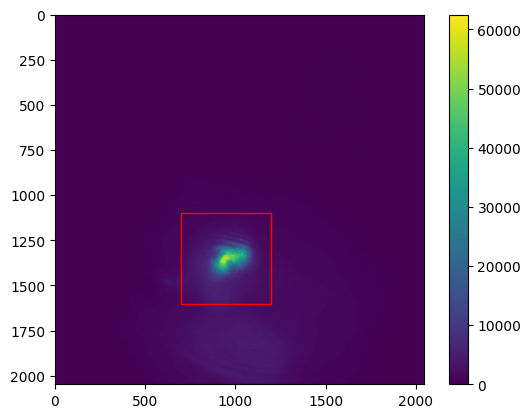

In [141]:
roi = [700, 1100, 1200, 1600]
plt.imshow(img0*binary_mask)
plt.gca().add_patch(patches.Rectangle((roi[0], roi[1]), roi[2]-roi[0], roi[3]-roi[1], fill=False, edgecolor='red'))
plt.colorbar()

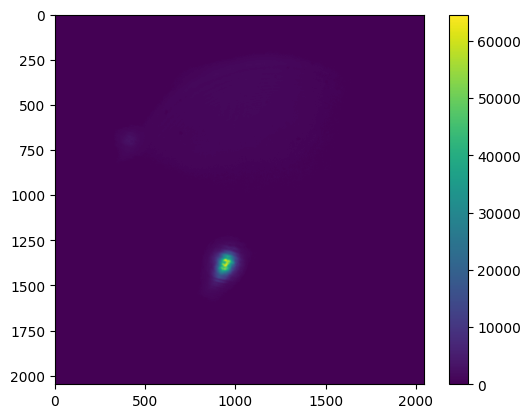

In [ ]:
plt.imshow(img0*binary_mask)
plt.colorbar()

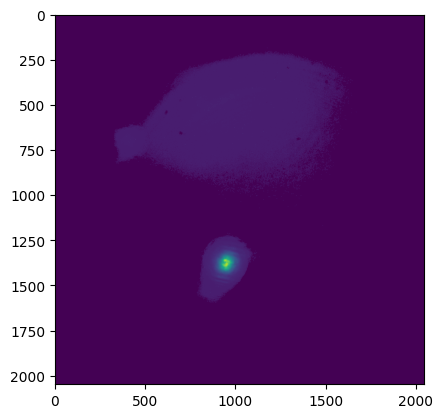

In [68]:
img7 = io.imread(files05[4]).astype(np.int64)
plt.imshow(img7*binary_mask)

In [69]:
img7.max()

51170

In [121]:
def get_power(path):
    """Get the exposure time from the settings file.
    Args: path: string with the path to the directory with the settings file.
    Returns: texp: float with the exposure time.
    """
    file_settings = path + '/settings.json'
    df_settings = pd.read_csv(file_settings, sep=':', names=['setting', 'value'], index_col='setting')
    power = float(df_settings.loc['POWER(uW)'].values[0])
    print(f'P = {power} µW')
    return power

In [274]:
ROOT

'/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/data/img/time/'

In [281]:
filtstats_path = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/code/imag_analisis/filter_stats.csv'
filtstats = pd.read_csv(filtstats_path, index_col=0)
filtAv = filtstats.central_lambda[:10]
filtUn = filtstats.range_width[:10]
filtQE = filtstats.mean_qe[:10]

In [282]:
def prepare_spectrum(path, roi=None):
    """Prepare the spectrum of the images in the given list of files
    Args: files: list of strings with the paths to the images.
          roi: list of integers with the coordinates of the region of interest.
    Returns: cntQe: 1D numpy array with the counts per QE."""
    
    files = sorted(glob(path + '*.tif'))
    power = get_power(path)
    nfilt = len(files)

    for f in files:
        if 'Center-NA' in f:
            f0 = f
        elif 'Dark_Blind' in f:
            fdark = f
    img0 = io.imread(f0).astype(np.int64)
    name = os.path.split(f0)[-1]
    print('Finding FOV on image with No Filters: ', name)
    binary_mask = fov_threshold(img0, method = 'yen')

    mask_disk = morphology.remove_small_objects(binary_mask, min_size=10)  # Remove small noise

    # img0[~mask_disk] = 0
    # imsize = mask_disk[mask_disk].shape  # Number of pixels in the circular mask
    if roi is not None:
        imroi = img0[roi[0]:roi[1], roi[2]:roi[3]]
        imsize = imroi.shape[0] * imroi.shape[1]
    
    print(f'Imsize: {imsize} pixels')
    offset = 100 * imsize

    img_dark = io.imread(fdark).astype(np.int64)

    avInt = []
    unInt = []
    for i in range(nfilt - 2):
        # print('Processing file: ', os.path.split(files[i])[-1])
        img = io.imread(files[i]).astype(np.int64)
        img -= img_dark
        img[~mask_disk] = 0

        if roi is not None:
            img = img[roi[0]:roi[1], roi[2]:roi[3]]

        intPx = (img.sum()) / imsize
        avInt.append(intPx)

        unPx = np.sqrt((img ** 2).sum()) / imsize
        unInt.append(unPx)

    avInt = np.array(avInt).ravel()
    unInt = np.array(unInt).ravel()
    cntQe = avInt / filtQE
    cntQe /= power   # Divide by the QE and the power
    cntQe   /= (filtUn*2)  # Divide by the uncertainty in the transmission

    unInt /= filtQE
    unInt /= power
    unInt /= (filtUn*2)
    return cntQe, unInt

P = 961.0939 µW
P = 1025.6302 µW
P = 998.2712 µW
P = 1037.6548 µW


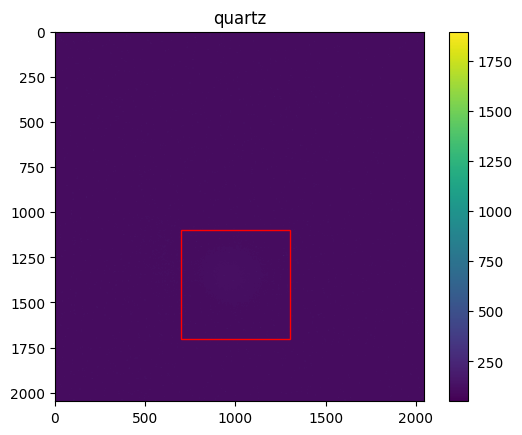

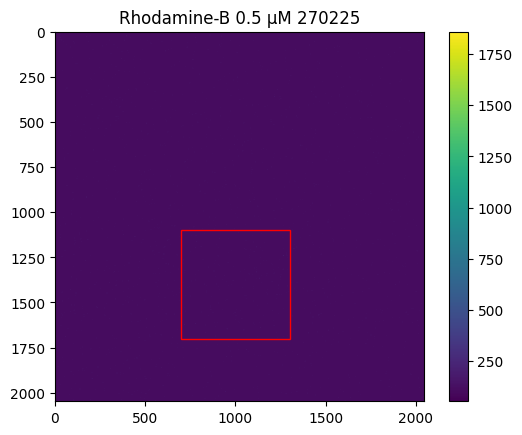

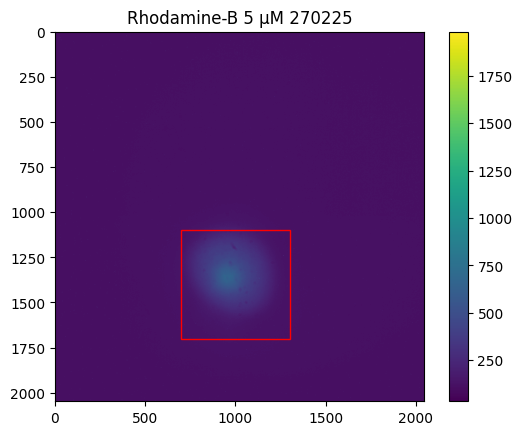

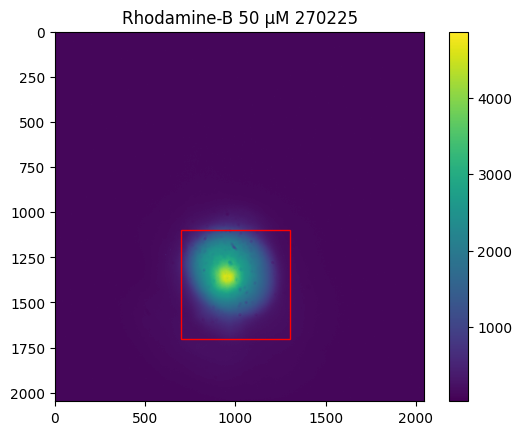

In [285]:
roi = [1100, 1700, 700, 1300]
paths = [path_fs, path_05, path_5, path_50]
for p in paths:
    files = sorted(glob(p + '*.tif'))
    power = get_power(p)
    nfilt = len(files)
    plt.figure()
    for f in files:
        if 'Center-605' in f:
            f0 = f

    img0 = io.imread(f0).astype(np.int64)
    name = p.split('/')[-3]
    imroi = img0[roi[0]:roi[1], roi[2]:roi[3]]
    plt.imshow(img0)
    plt.gca().add_patch(patches.Rectangle((roi[2], roi[0]), roi[3]-roi[2], roi[1]-roi[0], fill=False, edgecolor='red'))
    plt.colorbar()
    plt.title(name)

In [315]:
path_ref = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/spectra/reference_spectra/Rhodamine_B.csv'
rhb_ref = pd.read_csv(path_ref, names=['Wavelength', 'intensity'], skiprows=1, index_col=0)
path_fs = ROOT_SPEC + '/12-03-25/quartz/3/'
path_05 = ROOT_SPEC + '12-03-25/Rhodamine-B 0.5 µM 270225/2/'
path_5 = ROOT_SPEC + '12-03-25/Rhodamine-B 5 µM 270225/2/'
path_50 = ROOT_SPEC + '12-03-25/Rhodamine-B 50 µM 270225/2/'
roi = [1100, 1700, 700, 1300]
cfs, ufs = prepare_spectrum(path_fs, roi = roi)
c05, u05 = prepare_spectrum(path_05, roi = roi)
c5, u5 = prepare_spectrum(path_5, roi = roi)
c50, u50 = prepare_spectrum(path_50, roi = roi)

rhb_ref.intensity *= c50.max()

P = 961.0939 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-44-18.tif
Threshold: yen 0.7988281729631126
Imsize: 360000 pixels
P = 1025.6302 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-36-06.tif
Threshold: yen 0.7714844294823706
Imsize: 360000 pixels
P = 998.2712 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-26-21.tif
Threshold: yen 0.7402344369329512
Imsize: 360000 pixels
P = 1037.6548 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-18-53.tif
Threshold: yen 0.5996094704605639
Imsize: 360000 pixels


[Text(0.5, 0, 'Wavelength (nm)'),
 Text(0, 0.5, 'Counts/nm/px/µW'),
 None,
 Text(0.5, 1.0, 'Rhodamine-B + Fused silica substrate')]

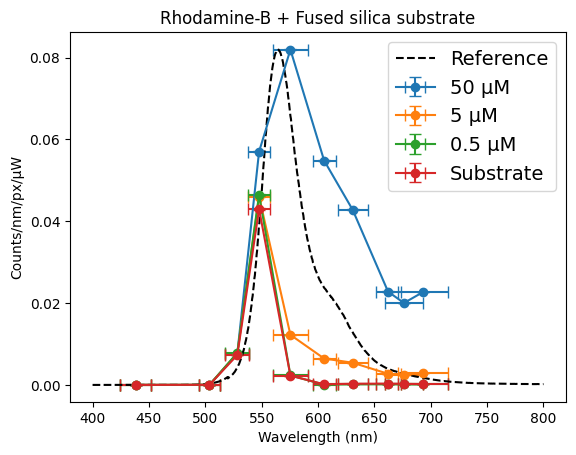

In [316]:
plt.errorbar(filtAv, c50, yerr=u50, xerr=filtUn, fmt='-o', label='50 µM')
plt.errorbar(filtAv, c5, yerr=u5, xerr=filtUn, fmt='-o', label='5 µM')
plt.errorbar(filtAv, c05, yerr=u05, xerr=filtUn, fmt='-o', label = '0.5 µM')
plt.errorbar(filtAv, cfs, yerr=ufs, xerr=filtUn, fmt='-o', label = 'Substrate')

rhb_ref.plot(y='intensity', ax=plt.gca(), label='Reference', color='black', linestyle='--')
plt.legend(fontsize=14)

plt.gca().set(xlabel='Wavelength (nm)', ylabel='Counts/nm/px/µW', yscale='linear', title='Rhodamine-B + Fused silica substrate')

# Subtract fused silica background

In [317]:
path_ref = '/Users/pabloherrero/Library/CloudStorage/GoogleDrive-qmlab@mail.huji.ac.il/My Drive/Ba Tagging/spectra/reference_spectra/Rhodamine_B.csv'
rhb_ref = pd.read_csv(path_ref, names=['Wavelength', 'intensity'], skiprows=1, index_col=0)
path_fs = ROOT_SPEC + '/12-03-25/quartz/3/'
path_05 = ROOT_SPEC + '12-03-25/Rhodamine-B 0.5 µM 270225/2/'
path_5 = ROOT_SPEC + '12-03-25/Rhodamine-B 5 µM 270225/2/'
path_50 = ROOT_SPEC + '12-03-25/Rhodamine-B 50 µM 270225/2/'

roi = [1100, 1700, 700, 1300]

cfs, ufs = prepare_spectrum(path_fs, roi = roi)
c05, u05 = prepare_spectrum(path_05, roi = roi)
c5, u5 = prepare_spectrum(path_5, roi = roi)
c50, u50 = prepare_spectrum(path_50, roi = roi)

c05 -= cfs
u05 = np.sqrt(u05**2 + ufs**2)
c5 -= cfs
u5 = np.sqrt(u5**2 + ufs**2)
c50 -= cfs
u50 = np.sqrt(u50**2 + ufs**2)

rhb_ref.intensity *= c50.max()

P = 961.0939 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-44-18.tif
Threshold: yen 0.7988281729631126
Imsize: 360000 pixels
P = 1025.6302 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-36-06.tif
Threshold: yen 0.7714844294823706
Imsize: 360000 pixels
P = 998.2712 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-26-21.tif
Threshold: yen 0.7402344369329512
Imsize: 360000 pixels
P = 1037.6548 µW
Finding FOV on image with No Filters:  Center-NA_Width-NA_12-18-53.tif
Threshold: yen 0.5996094704605639
Imsize: 360000 pixels


[Text(0.5, 0, 'Wavelength (nm)'),
 Text(0, 0.5, 'Counts/nm/px/µW'),
 None,
 Text(0.5, 1.0, 'Rhodamine-B (background subtracted)')]

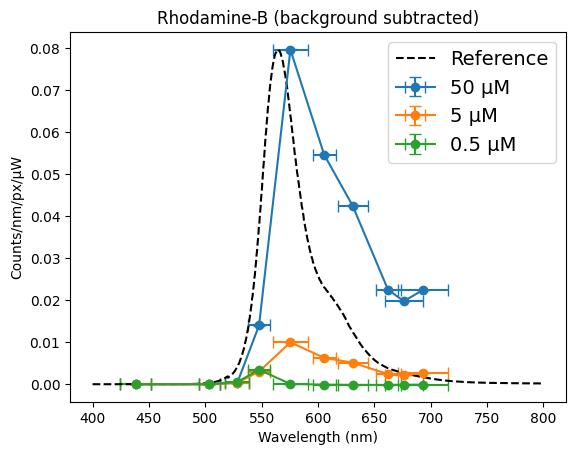

In [319]:
# plt.errorbar(filtAv, cfs, yerr=ufs, xerr=filtUn, fmt='-o', label = 'Substrate')
plt.errorbar(filtAv, c50, yerr=u50, xerr=filtUn, fmt='-o', label='50 µM')
plt.errorbar(filtAv, c5, yerr=u5, xerr=filtUn, fmt='-o', label='5 µM')
plt.errorbar(filtAv, c05, yerr=u05, xerr=filtUn, fmt='-o', label = '0.5 µM')

rhb_ref.plot(y='intensity', ax=plt.gca(), label='Reference', color='black', linestyle='--')
plt.legend(fontsize=14)

plt.gca().set(xlabel='Wavelength (nm)', ylabel='Counts/nm/px/µW', yscale='linear', title='Rhodamine-B (background subtracted)')

[Text(0.5, 0, 'Wavelength (nm)'),
 Text(0, 0.5, 'Counts/nm/px/µW'),
 None,
 Text(0.5, 1.0, 'Rhodamine-B')]

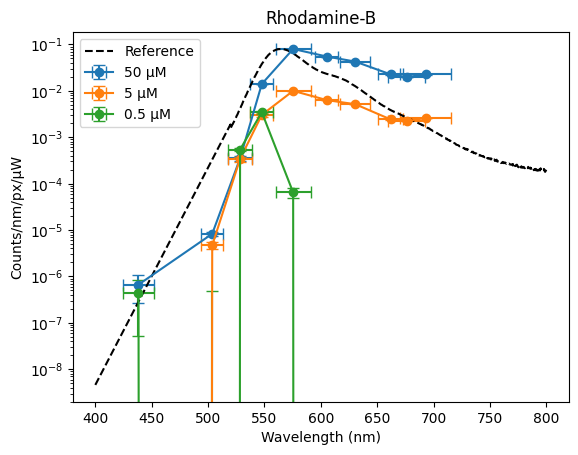

In [292]:
plt.errorbar(filtAv, c50, yerr=u50, xerr=filtUn, fmt='-o', label='50 µM')
plt.errorbar(filtAv, c5, yerr=u5, xerr=filtUn, fmt='-o', label='5 µM')
plt.errorbar(filtAv, c05, yerr=u05, xerr=filtUn, fmt='-o', label = '0.5 µM')
# plt.errorbar(filtAv, cfs, yerr=ufs, xerr=filtUn, fmt='-o', label = 'Substrate')
rhb_ref.plot(y='intensity', ax=plt.gca(), label='Reference', color='black', linestyle='--')
plt.legend()

plt.gca().set(xlabel='Wavelength (nm)', ylabel='Counts/nm/px/µW', yscale='log', title='Rhodamine-B')

[Text(0.5, 0, 'Wavelength (nm)'),
 Text(0, 0.5, 'Counts/nm/px/µW'),
 None,
 Text(0.5, 1.0, 'Rhodamine-B')]

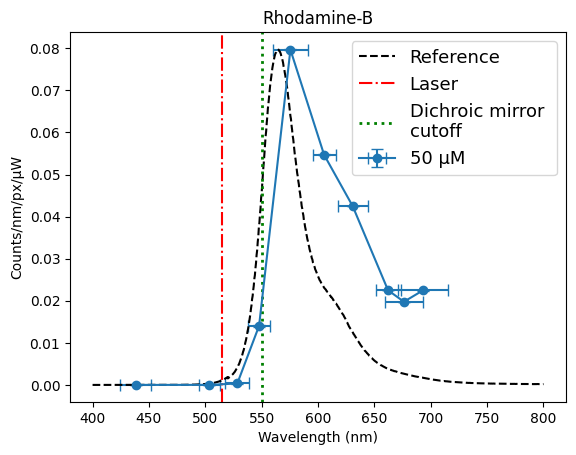

In [322]:
plt.errorbar(filtAv, c50, yerr=u50, xerr=filtUn, fmt='-o', label='50 µM')

rhb_ref.plot(y='intensity', ax=plt.gca(), label='Reference', color='black', linestyle='--')
plt.axvline(515, color='red', linestyle='-.', label='Laser')
plt.axvline(550, color='g', linestyle=':', lw = 2, label='Dichroic mirror \ncutoff')

plt.legend(fontsize=13)


plt.gca().set(xlabel='Wavelength (nm)', ylabel='Counts/nm/px/µW', yscale='linear', title='Rhodamine-B')

In [199]:
c50.max(), c5.max(), c05.max(), cfs.max()

(0.0007225813952316322,
 3.254667122666802e-05,
 5.3866213044872456e-05,
 1.0001585028182551e-05)

In [ ]:
c50.max(), c5.max(), c05.max(), cfs.max()

(0.0007325829802598147,
 4.254825625485057e-05,
 6.3867798073055e-05,
 1.0001585028182551e-05)